In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn import preprocessing as p

es = EarlyStopping(monitor = "val_loss", mode = "min", patience = 3)
EPOCHS = 100

df = pd.read_table('tested.csv', sep = ',')

In [2]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [3]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [4]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [5]:
df["Embarked"].value_counts()

S    270
C    102
Q     46
Name: Embarked, dtype: int64

In [6]:
df = df.drop(['PassengerId', 'Name', "Ticket", "Cabin"], axis = 1)

In [7]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,34.5,0,0,7.8292,Q
1,1,3,female,47.0,1,0,7.0000,S
2,0,2,male,62.0,0,0,9.6875,Q
3,0,3,male,27.0,0,0,8.6625,S
4,1,3,female,22.0,1,1,12.2875,S
...,...,...,...,...,...,...,...,...
413,0,3,male,NaN,0,0,8.0500,S
414,1,1,female,39.0,0,0,108.9000,C
415,0,3,male,38.5,0,0,7.2500,S
416,0,3,male,NaN,0,0,8.0500,S


In [8]:
df = pd.get_dummies(df)

In [9]:
df

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,34.5,0,0,7.8292,0,1,0,1,0
1,1,3,47.0,1,0,7.0000,1,0,0,0,1
2,0,2,62.0,0,0,9.6875,0,1,0,1,0
3,0,3,27.0,0,0,8.6625,0,1,0,0,1
4,1,3,22.0,1,1,12.2875,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
413,0,3,NaN,0,0,8.0500,0,1,0,0,1
414,1,1,39.0,0,0,108.9000,1,0,1,0,0
415,0,3,38.5,0,0,7.2500,0,1,0,0,1
416,0,3,NaN,0,0,8.0500,0,1,0,0,1


In [10]:
df = df.drop(['Sex_male', 'Embarked_S'], axis = 1)

In [11]:
df

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Embarked_C,Embarked_Q
0,0,3,34.5,0,0,7.8292,0,0,1
1,1,3,47.0,1,0,7.0000,1,0,0
2,0,2,62.0,0,0,9.6875,0,0,1
3,0,3,27.0,0,0,8.6625,0,0,0
4,1,3,22.0,1,1,12.2875,1,0,0
...,...,...,...,...,...,...,...,...,...
413,0,3,NaN,0,0,8.0500,0,0,0
414,1,1,39.0,0,0,108.9000,1,1,0
415,0,3,38.5,0,0,7.2500,0,0,0
416,0,3,NaN,0,0,8.0500,0,0,0


In [12]:
mean_value = df["Age"].mean()
df = df.fillna(mean_value)

In [13]:
columns = df.columns
columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female',
       'Embarked_C', 'Embarked_Q'],
      dtype='object')

In [14]:
cols_to_scale = ['Pclass','Age','Fare']

scaler = p.StandardScaler().fit(df[cols_to_scale])

df[cols_to_scale] = scaler.transform(df[cols_to_scale])

In [15]:
df

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Embarked_C,Embarked_Q
0,0,0.873482,0.334993,0,0,-0.498172,0,0,1
1,1,0.873482,1.325530,1,0,-0.513039,1,0,0
2,0,-0.315819,2.514175,0,0,-0.464854,0,0,1
3,0,0.873482,-0.259330,0,0,-0.483231,0,0,0
4,1,0.873482,-0.655545,1,1,-0.418237,1,0,0
...,...,...,...,...,...,...,...,...,...
413,0,0.873482,0.000000,0,0,-0.494213,0,0,0
414,1,-1.505120,0.691586,0,0,1.313968,1,1,0
415,0,0.873482,0.651965,0,0,-0.508557,0,0,0
416,0,0.873482,0.000000,0,0,-0.494213,0,0,0


In [16]:
X = df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Embarked_C', 'Embarked_Q']]
y = df[['Survived']]

In [17]:
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state=1)

In [23]:
model = Sequential()
model.add(Dense(16, activation = 'relu'))
model.add(Dense(8, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

In [24]:
model.compile(loss = "binary_crossentropy", optimizer = 'adam', metrics=["accuracy"])

In [25]:
history=  model.fit(x_train, y_train, epochs = EPOCHS, validation_data = (x_test, y_test) , callbacks = [es])

Epoch 1/100
11/11 [==============================] - 1s 40ms/step - loss: 0.7641 - accuracy: 0.3772 - val_loss: 0.7203 - val_accuracy: 0.3095
Epoch 2/100
11/11 [==============================] - 0s 9ms/step - loss: 0.7293 - accuracy: 0.3772 - val_loss: 0.6943 - val_accuracy: 0.3095
Epoch 3/100
11/11 [==============================] - 0s 9ms/step - loss: 0.6988 - accuracy: 0.3772 - val_loss: 0.6722 - val_accuracy: 0.3095
Epoch 4/100
11/11 [==============================] - 0s 8ms/step - loss: 0.6722 - accuracy: 0.3772 - val_loss: 0.6520 - val_accuracy: 0.3095
Epoch 5/100
11/11 [==============================] - 0s 9ms/step - loss: 0.6502 - accuracy: 0.3772 - val_loss: 0.6348 - val_accuracy: 0.3095
Epoch 6/100
11/11 [==============================] - 0s 9ms/step - loss: 0.6291 - accuracy: 0.3772 - val_loss: 0.6166 - val_accuracy: 0.3095
Epoch 7/100
11/11 [==============================] - 0s 9ms/step - loss: 0.6102 - accuracy: 0.3772 - val_loss: 0.6001 - val_accuracy: 0.3095
Epoch 8/100


Epoch 59/100
11/11 [==============================] - 0s 9ms/step - loss: 0.0080 - accuracy: 0.3772 - val_loss: 0.0090 - val_accuracy: 0.3095
Epoch 60/100
11/11 [==============================] - 0s 8ms/step - loss: 0.0076 - accuracy: 0.3772 - val_loss: 0.0086 - val_accuracy: 0.3095
Epoch 61/100
11/11 [==============================] - 0s 7ms/step - loss: 0.0072 - accuracy: 0.3772 - val_loss: 0.0082 - val_accuracy: 0.3095
Epoch 62/100
11/11 [==============================] - 0s 8ms/step - loss: 0.0069 - accuracy: 0.3772 - val_loss: 0.0078 - val_accuracy: 0.3095
Epoch 63/100
11/11 [==============================] - 0s 10ms/step - loss: 0.0065 - accuracy: 0.3772 - val_loss: 0.0074 - val_accuracy: 0.3095
Epoch 64/100
11/11 [==============================] - 0s 10ms/step - loss: 0.0063 - accuracy: 0.3772 - val_loss: 0.0071 - val_accuracy: 0.3095
Epoch 65/100
11/11 [==============================] - 0s 9ms/step - loss: 0.0060 - accuracy: 0.3772 - val_loss: 0.0068 - val_accuracy: 0.3095
Epoc

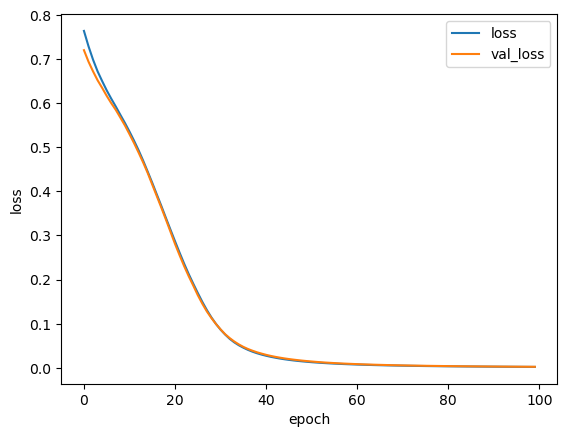

In [26]:
hist = pd.DataFrame(history.history)
plt.plot(hist.loss, label = "loss")
plt.plot(hist.val_loss, label = "val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

In [22]:
output = model.evaluate(x_test, y_test)

3/3 [==============================] - 0s 8ms/step - loss: 0.0021 - accuracy: 1.0000
